# Principal Component Analysis (PCA)

- PCA is a dimensionality reduction technique used to reduce features while preserving maximum variance (information) in the dataset.

## Steps in PCA

### 1. Mean Centering / Standardization
- First, apply StandardScaler to center the data around mean = 0 and standard deviation = 1.

### 2. Find Covariance Matrix
- Covariance matrix shows the relationship between features.
- Diagonal values represent variances of features.
- Non-diagonal values represent covariance and are symmetric (transpose-corresponding).

### 3. Find Eigenvalues and Eigenvectors
- Eigenvectors represent directions of variance.
- Eigenvalues represent the magnitude of variance in those directions.
- The eigenvector with the highest eigenvalue always points toward the direction of maximum variance in the dataset.

## Main Intuition
- PCA selects the directions with maximum variance and projects the data onto those directions to reduce dimensions while retaining important information.

In [21]:
import numpy as np  
import pandas as pd  

np.random.seed(23)  # Fix random seed so results remain same every time

# Creating random dataset for Class 1

mu_vec1 = np.array([0,0,0])  # Mean vector for class 1
cov_mat1 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])  # Covariance matrix for class 1

class1_sample = np.random.multivariate_normal(
    mu_vec1,  # Mean values
    cov_mat1,  # Covariance matrix
    20  # Number of samples
)

df = pd.DataFrame(
    class1_sample,
    columns=['feature1','feature2','feature3']
)  # Convert generated samples into DataFrame

df['target'] = 1  # Assign target label = 1


# Creating random dataset for Class 2

mu_vec2 = np.array([1,1,1])  # Mean vector for class 2

cov_mat2 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])  # Covariance matrix for class 2

class2_sample = np.random.multivariate_normal(
    mu_vec2,
    cov_mat2,
    20
)

df1 = pd.DataFrame(
    class2_sample,
    columns=['feature1','feature2','feature3']
)  # Convert samples into DataFrame


df1['target'] = 0  # Assign target label = 0


# Combine both class datasets together
df = pd.concat(
    [df, df1],
    ignore_index=True
)


# Shuffle dataset randomly
df = df.sample(40)

In [22]:
df.head()
# its a 3D data 

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


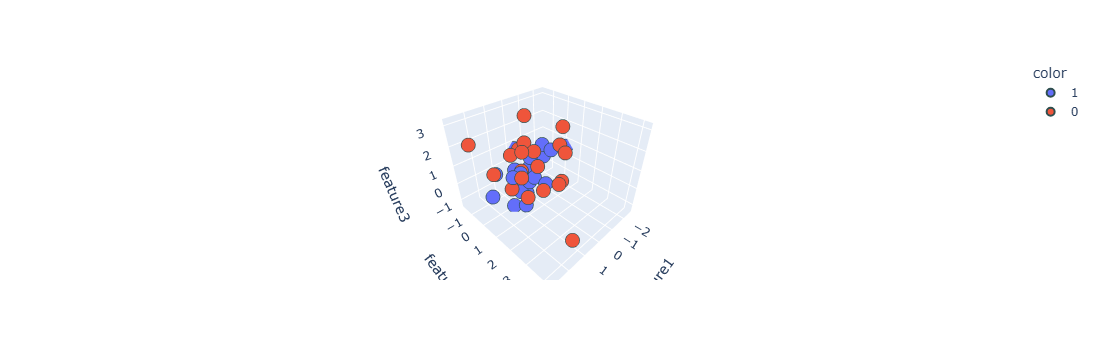

In [23]:
import plotly.express as px
# 3D visual of data 

#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=8,   # size of dots(values)
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [24]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [25]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]]) #col1 , col 2 , col 3 
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [26]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [27]:
# we have 3D data that's why we have 3 Eigen values 
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [28]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


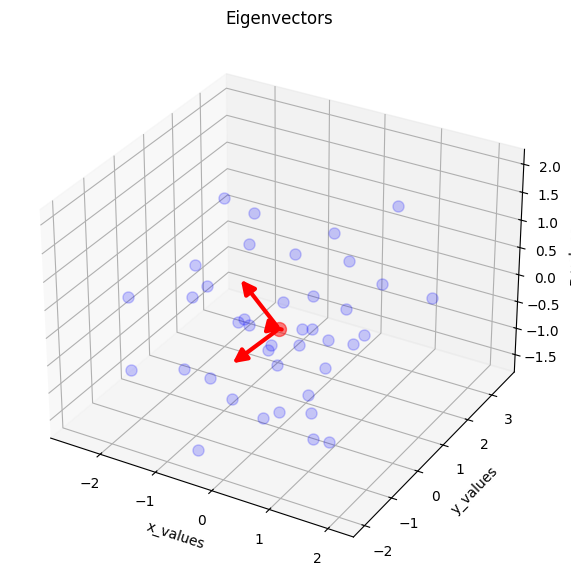

In [29]:
# Enables matplotlib graphs inside Jupyter Notebook
%pylab inline  

from matplotlib import pyplot as plt  # Import plotting library
from mpl_toolkits.mplot3d import Axes3D  # Import 3D plotting tools
from mpl_toolkits.mplot3d import proj3d  # Converts 3D coordinates into 2D view
from matplotlib.patches import FancyArrowPatch  # Used for creating custom arrows


class Arrow3D(FancyArrowPatch):  # Custom class for creating 3D arrows
    
    def __init__(self, xs, ys, zs, *args, **kwargs):  # Constructor
        super().__init__((0,0), (0,0), *args, **kwargs)  # Initialize parent class
        self._verts3d = xs, ys, zs  # Store arrow coordinates

    def do_3d_projection(self, renderer=None):  # Handles 3D depth projection
        xs3d, ys3d, zs3d = self._verts3d  # Extract coordinates
        xs, ys, zs = proj3d.proj_transform(  # Convert 3D to 2D projection
            xs3d, ys3d, zs3d,
            self.axes.get_proj()
        )
        
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))  # Set arrow positions
        return np.min(zs)  # Return minimum depth value

    def draw(self, renderer):  # Draw function
        xs3d, ys3d, zs3d = self._verts3d  # Extract coordinates
        xs, ys, zs = proj3d.proj_transform(  # Project 3D points to 2D
            xs3d, ys3d, zs3d,
            self.axes.get_proj()
        )
        
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))  # Set arrow positions
        super().draw(renderer)  # Draw arrow


fig = plt.figure(figsize=(7,7))  # Create figure canvas
ax = fig.add_subplot(111, projection='3d')  # Add 3D subplot

ax.plot(  # Plot all dataset points
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',  # Circle markers
    markersize=8,  # Marker size
    color='blue',  # Marker color
    alpha=0.2  # Transparency
)

ax.plot(  # Plot mean center point
    [df['feature1'].mean()],
    [df['feature2'].mean()],
    [df['feature3'].mean()],
    'o',
    markersize=10,
    color='red',
    alpha=0.5
)

for v in eigen_vectors.T:  # Loop through eigenvectors
    
    a = Arrow3D(  # Create arrow  
        [df['feature1'].mean(), v[0]],  # X coordinates
        [df['feature2'].mean(), v[1]],  # Y coordinates
        [df['feature3'].mean(), v[2]],  # Z coordinates
        mutation_scale=20,  # Arrow size
        lw=3,  # Line width
        arrowstyle="-|>",  # Arrow style
        color="r"  # Arrow color
    )
    
    ax.add_artist(a)  # Add arrow to graph


ax.set_xlabel('x_values')  # Set x-axis label
ax.set_ylabel('y_values')  # Set y-axis label
ax.set_zlabel('z_values')  # Set z-axis label


plt.title('Eigenvectors')  # Set graph title
plt.show()  # Display graph

In [33]:
# converting 3D to 2D , thats why we have taken col 1 and col 2 only 
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [34]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 (Original dataset) - 3,2 (New Dataset)
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


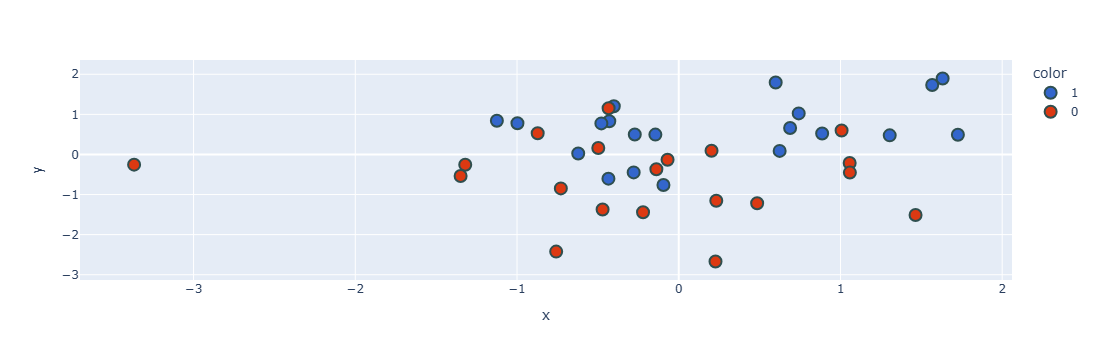

In [35]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()